In [1]:
# Interim Submission — Play Store Reviews Scraping & Preprocessing
# **Goal:** Scrape reviews for CBE, BOA, Dashen; preprocess; produce cleaned CSVs; run a small sentiment sample and quick EDA for interim report.


In [2]:
# Install required packages
!pip install --quiet google-play-scraper pandas tqdm python-dateutil nltk vaderSentiment transformers torch matplotlib seaborn
# Note: transformers + torch are optional for HF model; VADER is fast and sufficient for interim sample


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.1 MB/s eta 0:00:00


In [3]:
import os
from pathlib import Path
import time
import pandas as pd
from tqdm import tqdm
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment tools (VADER for quick sample)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

try:
    from transformers import pipeline
    HF_AVAILABLE = True
except Exception:
    HF_AVAILABLE = False

# google-play-scraper import - if import fails, install the correct package first
try:
    from google_play_scraper import reviews, Sort
except Exception as e:
    raise e

# Files & folders
BASE = Path.cwd()
DATA_RAW = BASE / "data" / "raw"
DATA_PROCESSED = BASE / "data" / "processed"
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)

TARGET_PER_APP = 400  # target per bank for interim


In [4]:
## 📦 App Package IDs

# Below are the Play Store package IDs for the mobile banking apps we are analyzing.
# These IDs are extracted from the Play Store URLs (everything after `id=`).

# - **CBE Mobile Banking**
#   Package ID: `com.combanketh.mobilebanking`
#   Source: https://play.google.com/store/apps/details?id=com.combanketh.mobilebanking

# - **Bank of Abyssinia (BOA)**
#   Package ID: `com.boa.boaMobileBanking`
#   Source: https://play.google.com/store/apps/details?id=com.boa.boaMobileBanking

# - **Dashen Bank (Amole App)**
#   Package ID: `com.cr2.amolelight`
#   Source: https://play.google.com/store/apps/details?id=com.cr2.amolelight

# These IDs will be used for scraping app reviews from the Google Play Store API.


In [5]:
# Replace these package names with the real ones
APPS = {
    "CBE": "com.combanketh.mobilebanking",     # CBE app
    "BOA": "com.boa.boaMobileBanking",         # Bank of Abyssinia (BoA) app
    "Dashen": "com.cr2.amolelight"             # Dashen Bank / Amole app
}

def fetch_reviews_for_app(package_name, lang='en', country='us', batch_size=200, max_reviews=TARGET_PER_APP):
    """
    Fetch reviews using google_play_scraper.reviews.
    Returns list of review dicts (library's format).
    """
    all_revs = []
    continuation_token = None
    pbar = tqdm(total=max_reviews, desc=f"Fetching {package_name}")
    while len(all_revs) < max_reviews:
        try:
            revs, continuation_token = reviews(
                package_name,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=batch_size,
                continuation_token=continuation_token
            )
            if not revs:
                break
            all_revs.extend(revs)
            pbar.update(len(revs))
            if continuation_token is None:
                break
            time.sleep(0.5)  # polite delay
        except Exception as e:
            print("Fetch error:", e)
            time.sleep(3)
            # continue trying
    pbar.close()
    return all_revs[:max_reviews]


def normalize_review_record(raw):
    """
    Accepts a review dict from google_play_scraper and returns normalized record.
    Fields: review_text, rating, review_date (YYYY-MM-DD), raw_date_obj (if available)
    """
    # library keys typically: 'content', 'score', 'at' (datetime)
    text = raw.get('content') or raw.get('review') or raw.get('text') or ""
    rating = raw.get('score') or raw.get('rating') or None
    raw_date = raw.get('at') or raw.get('date') or None
    if raw_date:
        try:
            if isinstance(raw_date, str):
                dt = parser.parse(raw_date)
            else:
                dt = raw_date
            date_iso = dt.strftime("%Y-%m-%d")
        except Exception:
            date_iso = ""
    else:
        date_iso = ""
    return {
        "review_text": text.strip(),
        "rating": int(rating) if rating is not None else None,
        "review_date": date_iso
    }


In [6]:
# Main scraping loop - saves per-bank raw CSVs
for bank, pkg in APPS.items():
    print(f"\n=== Scraping {bank}: {pkg} ===")
    raw_list = fetch_reviews_for_app(pkg, max_reviews=TARGET_PER_APP)
    print(f"Fetched {len(raw_list)} raw items for {bank}")
    # Normalize list to DataFrame
    rows = []
    for r in raw_list:
        nr = normalize_review_record(r)
        nr.update({"bank": bank, "source": "Google Play", "app_package": pkg})
        rows.append(nr)
    df_bank = pd.DataFrame(rows)
    out_path = DATA_RAW / f"{bank.lower()}_raw.csv"
    df_bank.to_csv(out_path, index=False, encoding='utf-8')
    print(f"Saved raw: {out_path} ({len(df_bank)} rows)")



=== Scraping CBE: com.combanketh.mobilebanking ===


Fetching com.combanketh.mobilebanking: 100%|██████████| 400/400 [00:01<00:00, 304.05it/s]


Fetched 400 raw items for CBE
Saved raw: /content/data/raw/cbe_raw.csv (400 rows)

=== Scraping BOA: com.boa.boaMobileBanking ===


Fetching com.boa.boaMobileBanking: 100%|██████████| 400/400 [00:01<00:00, 301.86it/s]


Fetched 400 raw items for BOA
Saved raw: /content/data/raw/boa_raw.csv (400 rows)

=== Scraping Dashen: com.cr2.amolelight ===


Fetching com.cr2.amolelight: 100%|██████████| 400/400 [00:01<00:00, 266.68it/s]

Fetched 400 raw items for Dashen
Saved raw: /content/data/raw/dashen_raw.csv (400 rows)


In [7]:
# Combine raw CSVs into a single file and perform basic cleaning
raw_files = list(DATA_RAW.glob("*_raw.csv"))
print("Raw files:", raw_files)

dfs = []
for f in raw_files:
    df = pd.read_csv(f)
    df['review_text'] = df['review_text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    # convert empty strings to NaN
    df['review_text'].replace('', pd.NA, inplace=True)
    df['review_date'].replace('', pd.NA, inplace=True)
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print("Combined shape:", combined.shape)

# Drop duplicates (same text + same bank) and rows without text & rating
before = len(combined)
combined.drop_duplicates(subset=['review_text','bank'], inplace=True)
combined = combined[(combined['review_text'].notna()) | (combined['rating'].notna())]
after = len(combined)
print(f"Dropped {before-after} duplicates/empty rows. Remaining: {after}")

# Normalize date column to YYYY-MM-DD (leave NaT when invalid)
combined['review_date'] = pd.to_datetime(combined['review_date'], errors='coerce').dt.date

# Reorder & select columns
combined_clean = combined[['review_text','rating','review_date','bank','source','app_package']]

# Save processed combined CSV
combined_clean_path = DATA_PROCESSED / "combined_clean_reviews.csv"
combined_clean.to_csv(combined_clean_path, index=False, encoding='utf-8')
print("Saved cleaned combined CSV:", combined_clean_path)


Raw files: [PosixPath('/content/data/raw/boa_raw.csv'), PosixPath('/content/data/raw/cbe_raw.csv'), PosixPath('/content/data/raw/dashen_raw.csv')]
Combined shape: (1200, 6)
Dropped 198 duplicates/empty rows. Remaining: 1002
Saved cleaned combined CSV: /content/data/processed/combined_clean_reviews.csv


/tmp/ipython-input-3513858260.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review_text'].replace('', pd.NA, inplace=True)
/tmp/ipython-input-3513858260.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [8]:
# KPI checks: reviews per bank, % missing text/rating
df = pd.read_csv(combined_clean_path, parse_dates=['review_date'])
counts = df.groupby('bank').size().reset_index(name='counts')
missing_text_pct = df['review_text'].isna().mean() * 100
missing_rating_pct = df['rating'].isna().mean() * 100

print("Counts per bank:")
print(counts.to_string(index=False))
print(f"\nMissing text: {missing_text_pct:.2f}%")
print(f"Missing rating: {missing_rating_pct:.2f}%")


Counts per bank:
  bank  counts
   BOA     352
   CBE     326
Dashen     324

Missing text: 0.00%
Missing rating: 0.00%


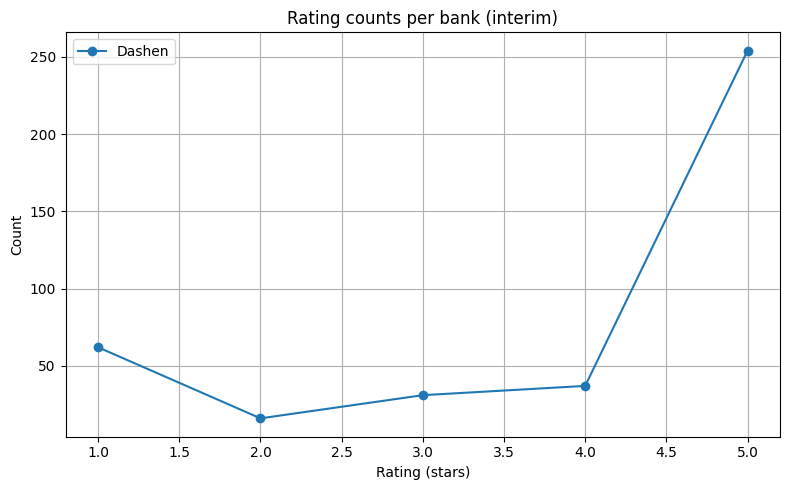

In [10]:
# Simple plot: rating distribution per bank
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for bank in df['bank'].unique():
    subset = df[df['bank']==bank]
    counts = subset['rating'].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker='o', label=bank)
plt.xlabel("Rating (stars)")
plt.ylabel("Count")
plt.title("Rating counts per bank (interim)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# Quick token frequency (not TF-IDF) — top 20 words overall and per bank
from collections import Counter
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))

def top_words(texts, n=20):
    ctr = Counter()
    for t in texts.astype(str):
        # simple tokenization
        tokens = re.findall(r'\b[a-zA-Z]{2,}\b', t.lower())
        tokens = [tok for tok in tokens if tok not in STOP]
        ctr.update(tokens)
    return ctr.most_common(n)

print("Top words overall:", top_words(df['review_text'], 20))
for bank in df['bank'].unique():
    print(f"\nTop words for {bank}:", top_words(df[df['bank']==bank]['review_text'], 20))


Top words overall: [('app', 156), ('good', 80), ('best', 51), ('nice', 35), ('bank', 34), ('use', 29), ('dashen', 22), ('amole', 20), ('banking', 20), ('please', 19), ('time', 19), ('like', 16), ('update', 16), ('one', 16), ('work', 16), ('account', 13), ('easy', 13), ('mobile', 12), ('always', 12), ('fast', 12)]

Top words for Dashen: [('app', 156), ('good', 80), ('best', 51), ('nice', 35), ('bank', 34), ('use', 29), ('dashen', 22), ('amole', 20), ('banking', 20), ('please', 19), ('time', 19), ('like', 16), ('update', 16), ('one', 16), ('work', 16), ('account', 13), ('easy', 13), ('mobile', 12), ('always', 12), ('fast', 12)]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
# Use VADER for a quick sample on first 200 reviews (fast)
analyzer = SentimentIntensityAnalyzer()

sample = df.sample(min(200, len(df)), random_state=42).copy()
sample['vader_compound'] = sample['review_text'].fillna("").apply(lambda x: analyzer.polarity_scores(x)['compound'])
# Map compound to label (simple rule)
def label_from_compound(c):
    if c >= 0.05:
        return "POSITIVE"
    elif c <= -0.05:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

sample['vader_label'] = sample['vader_compound'].apply(label_from_compound)
sample_path = DATA_PROCESSED / "vader_sentiment_sample.csv"
sample.to_csv(sample_path, index=False, encoding='utf-8')
print("Saved sentiment sample:", sample_path)
sample[['bank','rating','review_text','vader_compound','vader_label']].head(10)


Saved sentiment sample: /content/data/processed/vader_sentiment_sample.csv


,bank,rating,review_text,vader_compound,vader_label
209,Dashen,5,Student,0.0000,NEUTRAL
280,Dashen,5,Excellent quality Applications Dashen bank for...,0.5719,POSITIVE
33,Dashen,5,Best app,0.6369,POSITIVE
210,Dashen,2,Please apply!cardless cash out system🙏,0.3802,POSITIVE
93,Dashen,4,Generic error how tofix,-0.4019,NEGATIVE
84,Dashen,2,"The app is cool, but unlike other banks they d...",-0.4678,NEGATIVE
329,Dashen,2,Vary good,0.4404,POSITIVE
94,Dashen,5,Fast and suitable to learn.,0.0000,NEUTRAL
266,Dashen,5,Nice app,0.4215,POSITIVE
126,Dashen,5,Deshan bank,0.0000,NEUTRAL


In [13]:
if HF_AVAILABLE:
    clf = pipeline("sentiment-analysis", truncation=True)
    small = df.sample(min(50, len(df)), random_state=1).copy()
    hf_labels, hf_scores = [], []
    for txt in small['review_text'].fillna("").tolist():
        try:
            out = clf(txt[:512])[0]
            hf_labels.append(out['label'])
            hf_scores.append(out['score'])
        except Exception as e:
            hf_labels.append(None)
            hf_scores.append(None)
    small['hf_label'] = hf_labels
    small['hf_score'] = hf_scores
    small.to_csv(DATA_PROCESSED / "hf_sentiment_sample.csv", index=False)
    print("Saved HF sample to data/processed/hf_sentiment_sample.csv")
else:
    print("Transformers pipeline not available in this environment.")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Saved HF sample to data/processed/hf_sentiment_sample.csv


In [14]:
# Using VADER sample: average compound by rating
import numpy as np
if 'vader_compound' in sample.columns:
    agg = sample.groupby('rating')['vader_compound'].agg([np.mean, 'count']).reset_index()
    print("VADER compound mean by rating (sample):")
    print(agg.to_string(index=False))
else:
    print("No VADER sample found.")


VADER compound mean by rating (sample):
 rating      mean  count
      1 -0.146509     23
      2  0.115556      9
      3  0.226778     18
      4  0.409818     22
      5  0.429677    128


/tmp/ipython-input-2909415445.py:4: FutureWarning: The provided callable <function mean at 0x7b54d2770220> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg = sample.groupby('rating')['vader_compound'].agg([np.mean, 'count']).reset_index()


In [16]:

for p in (DATA_RAW.glob("*.csv")):
    print("RAW:", p)
for p in (DATA_PROCESSED.glob("*.csv")):
    print("PROCESSED:", p)


RAW: /content/data/raw/boa_raw.csv
RAW: /content/data/raw/cbe_raw.csv
RAW: /content/data/raw/dashen_raw.csv
PROCESSED: /content/data/processed/hf_sentiment_sample.csv
PROCESSED: /content/data/processed/combined_clean_reviews.csv
PROCESSED: /content/data/processed/vader_sentiment_sample.csv
